# Trabajo Práctico N.º 2 — Embeddings y búsqueda semántica

**Procesamiento de Lenguaje Natural · TUIA · UNR**

**Integrantes:** Josías Calabozo · Sharo Giuntoli · Ismael Darruiz · Sebastián Di Carlo

**Corpus:** los 200 libros de la categoría "Los más comentados" de Lectulandia, extraídos en el TP1 (`../P1/data/libros.csv`).

| Sección | Parte del enunciado |
|---|---|
| 1. Preparación | — |
| 2. Análisis inicial del corpus | §4, "Primer análisis del corpus" |
| 3. El corpus en dos versiones | §4.A |
| 4. Línea de base TF-IDF y búsqueda | §5 (línea de base) y requisitos técnicos |
| 5. Word2Vec propio contra SBW | §4.B |
| 6. Modelos de oración | §4.C |
| 7. Comparación y visualización | §4.D |
| 8. Evaluación con precision@k | §5 |

**Cómo ejecutarlo:** ver el [README](README.md) (entorno, descarga de SBW y modelos de oración).

---
# 1. Preparación

In [1]:
import json
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from gensim.models import KeyedVectors, Word2Vec
from langdetect import DetectorFactory, detect
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"   # aviso de la caché de Hugging Face en Windows

SEMILLA = 42
RUTA_CORPUS = "../P1/data/libros.csv"
RUTA_QUERIES = "data/queries.json"
RUTA_SBW = "models/SBW-vectors-300-min5.bin.gz"
os.makedirs("data", exist_ok=True)   # acá se guardan los embeddings calculados

nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("spanish"))

In [2]:
libros = pd.read_csv(RUTA_CORPUS)
libros["lista_generos"] = libros["generos"].str.split(" | ", regex=False)   # "Drama | Novela" → ["Drama", "Novela"]
libros["n_palabras"] = libros["sinopsis"].str.split().str.len()

print(f"{len(libros)} libros, {libros.shape[1]} columnas")
libros[["titulo", "autores", "generos", "serie", "n_palabras"]].head()

200 libros, 15 columnas


,titulo,autores,generos,serie,n_palabras
0,La chica del tren,Paula Hawkins,Intriga | Novela | Policíaco,NaN,115
1,El libro negro de la Nueva Izquierda,Agustín Laje | Nicolás Márquez,Ciencias sociales | Ensayo,NaN,366
2,Ready Player One,Ernest Cline,Ciencia ficción,NaN,186
3,It,Stephen King,Terror,NaN,142
4,La verdad sobre el caso Harry Quebert,Joël Dicker,Novela | Policíaco,Marcus Goldman,144


---
# 2. Análisis inicial del corpus

Antes de representar el texto, miramos qué tenemos y respondemos las cuatro preguntas del comienzo de la sección 4 del enunciado.

> El enunciado habla de "12 documentos": ese bloque parece venir de otro material. Nuestro corpus tiene 200 libros, y respondemos con esos datos.

Libros según cantidad de géneros: {1: 31, 2: 103, 3: 56, 4: 9, 5: 1}
Listas de géneros en orden alfabético: 100%


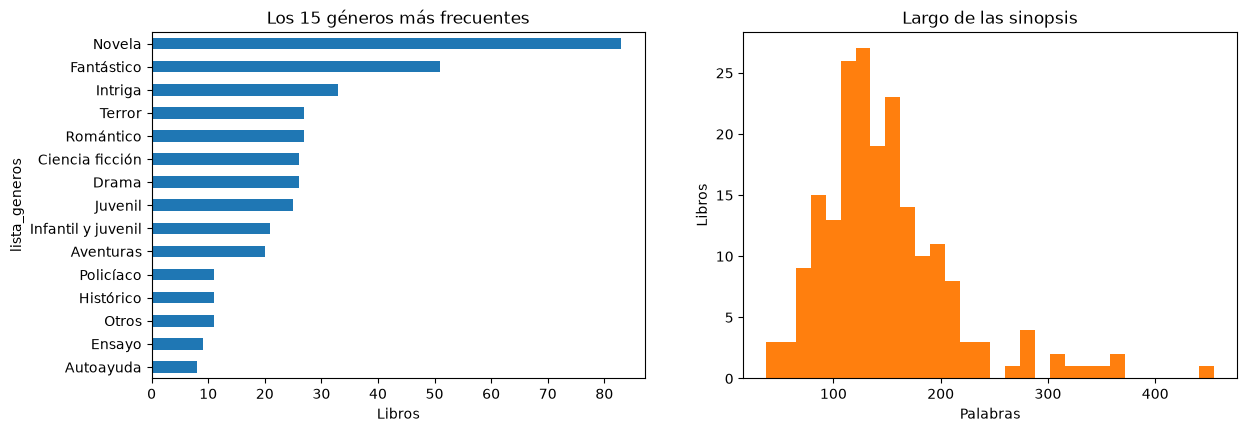

count    200.0
mean     149.0
std       63.0
min       37.0
25%      111.0
50%      136.0
75%      174.0
max      455.0


In [3]:
# Cada libro puede tener varios géneros
print("Libros según cantidad de géneros:", libros["lista_generos"].str.len().value_counts().sort_index().to_dict())

# Si las listas vienen en orden alfabético, "el primer género" no dice nada del libro
en_orden = libros["lista_generos"].apply(lambda generos: generos == sorted(generos))
print(f"Listas de géneros en orden alfabético: {en_orden.mean():.0%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
libros["lista_generos"].explode().value_counts().head(15).plot.barh(ax=axes[0])
axes[0].invert_yaxis()   # el más frecuente arriba
axes[0].set(title="Los 15 géneros más frecuentes", xlabel="Libros")
libros["n_palabras"].plot.hist(bins=30, ax=axes[1], color="tab:orange")
axes[1].set(title="Largo de las sinopsis", xlabel="Palabras", ylabel="Libros")
plt.show()
print(libros["n_palabras"].describe().round(0).to_string())

In [4]:
print(f"Libros que pertenecen a una serie: {libros['serie'].notna().sum()} (en {libros['serie'].nunique()} series)")
print(f"Autores con más libros: {libros['autores'].value_counts().head(4).to_dict()}")

# Mismo libro con otro título o en otra edición (los encontramos al revisar el listado del corpus)
REPETIDOS = [
    ("1984", "1984 (Trad. Miguel Temprano García)"),
    ("Cien años de soledad (Edición conmemorativa)", "Cien años de soledad (Ed. Ilustrada)"),
    ("Rebelión en la granja", "Rebelión en la granja (trad. Marcial Souto y Miguel Temprano García)"),
    ("El imperio final", "El Imperio Final. (Ed. revisada)"),
    ("Sapiens", "De animales a dioses"),
]
titulos = set(libros["titulo"])
assert all(a in titulos and b in titulos for a, b in REPETIDOS)
print(f"Pares de libros repetidos: {len(REPETIDOS)}")

Libros que pertenecen a una serie: 89 (en 67 series)
Autores con más libros: {'Stephen King': 12, 'Brandon Sanderson': 9, 'Sarah J. Maas': 5, 'J. K. Rowling': 5}
Pares de libros repetidos: 5


**Qué muestra**

- **169 de los 200 libros tienen más de un género**, y las listas vienen en **orden alfabético** en el 100 % de los casos: el primer género no es "el principal".
- **"Novela" aparece en 83 libros:** es un formato más que un tema.
- **Las sinopsis son cortas:** mediana de 136 palabras (de 37 a 455).
- **Hay sagas y autores muy representados** (89 libros en 67 series; Stephen King 12, Brandon Sanderson 9): "parecido" puede terminar significando "de la misma saga" o "del mismo autor".
- **Cinco libros están repetidos** con otro título o edición. Los dejamos y los usamos como prueba en la sección 7. En `queries.json`, si una edición es relevante, la otra también.

### Pregunta 1 — ¿Cuántas sinopsis hacen falta para que TF-IDF sea estable?

Los "términos característicos" de una sinopsis son sus 10 palabras de mayor peso TF-IDF. Como el IDF depende del corpus, cambian según con cuántas sinopsis se calcule. Para cada tamaño `n`, tomamos 20 muestras al azar de `n` sinopsis, calculamos TF-IDF solo con ellas y comparamos el top 10 de cada sinopsis con el que obtiene usando las 200, con la **similitud de Jaccard** (elementos en común sobre elementos totales).

     Jaccard medio  desvío
n                         
12            0.56    0.20
25            0.59    0.20
50            0.66    0.20
100           0.78    0.17
150           0.88    0.14


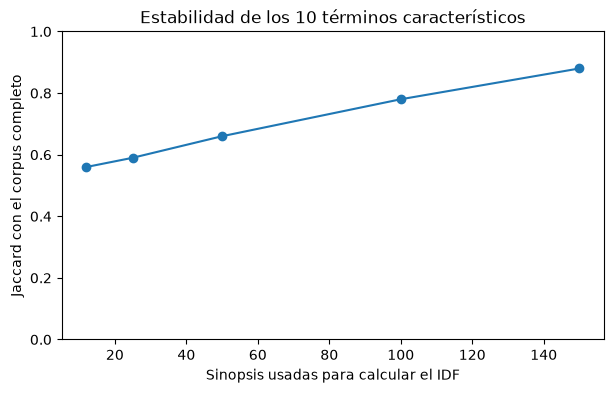

In [5]:
def top_terminos(textos, k=10):
    """Los k términos de mayor peso TF-IDF de cada texto, calculando el IDF solo con esos textos."""
    tfidf = TfidfVectorizer(stop_words=list(STOPWORDS))
    X = tfidf.fit_transform(textos)
    vocabulario = tfidf.get_feature_names_out()   # la palabra de cada columna
    tops = []
    for pesos in X.toarray():   # una fila por texto
        presentes = np.nonzero(pesos)[0]
        # Muchas palabras empatan en peso: se desempata por orden alfabético
        # para que el top no dependa del azar del ordenamiento
        orden = sorted(presentes, key=lambda j: (-pesos[j], vocabulario[j]))
        tops.append(set(vocabulario[orden[:k]]))
    return tops


def jaccard(a, b):
    return len(a & b) / len(a | b)


sinopsis = libros["sinopsis"].tolist()
referencia = top_terminos(sinopsis)   # calculado con las 200

rng = np.random.default_rng(SEMILLA)
filas = []
for n in [12, 25, 50, 100, 150]:
    for _ in range(20):
        muestra = rng.choice(len(sinopsis), size=n, replace=False)
        tops = top_terminos([sinopsis[i] for i in muestra])
        for i, top in zip(muestra, tops):
            filas.append({"n": n, "jaccard": jaccard(top, referencia[i])})

estabilidad = pd.DataFrame(filas).groupby("n")["jaccard"].agg(["mean", "std"]).round(2)
print(estabilidad.rename(columns={"mean": "Jaccard medio", "std": "desvío"}).to_string())

estabilidad["mean"].plot(marker="o", ylim=(0, 1), figsize=(7, 4))
plt.title("Estabilidad de los 10 términos característicos")
plt.xlabel("Sinopsis usadas para calcular el IDF")
plt.ylabel("Jaccard con el corpus completo")
plt.show()

**Respuesta**

- **Con 12 sinopsis, el top 10 coincide a medias** con el del corpus completo (Jaccard 0,56): con tan pocos documentos casi cualquier palabra es "rara", y el IDF no distingue lo característico de lo casual. Es el "casi ruido" del enunciado.
- **La coincidencia crece con el tamaño** (0,66 con 50; 0,78 con 100; 0,88 con 150) **y no llega a estabilizarse** en nuestro corpus. Con más datos se mediría igual: agregar sinopsis hasta que el Jaccard se mantenga alto (por ejemplo, por encima de 0,9).
- **Limitación:** la referencia son las mismas 200 sinopsis, y una muestra de 150 comparte tres cuartos de los documentos con ella; eso infla los valores altos.

### Pregunta 2 — Sesgo de las sinopsis promocionales

Las sinopsis de Lectulandia son contratapas, escritas para **vender** el libro. Buscamos expresiones típicas de marketing.

In [6]:
EXPRESIONES_PROMOCIONALES = ["éxito", "best seller", "bestseller", "millones de", "premio", "fenómeno",
                             "imprescindible", "aclamad", "obra maestra", "lectores", "traducid",
                             "saga", "adaptación", "película", "serie de"]

texto_minusculas = libros["sinopsis"].str.lower()
conteo = pd.Series({expresion: texto_minusculas.str.contains(expresion, regex=False).sum()
                    for expresion in EXPRESIONES_PROMOCIONALES})
print("Libros cuya sinopsis contiene cada expresión:")
print(conteo[conteo > 0].sort_values(ascending=False).to_string())

con_alguna = texto_minusculas.apply(lambda texto: any(e in texto for e in EXPRESIONES_PROMOCIONALES))
print(f"\nSinopsis con al menos una expresión promocional: {con_alguna.sum()} de {len(libros)}")

Libros cuya sinopsis contiene cada expresión:
millones de       14
éxito             11
premio             8
lectores           7
saga               5
serie de           5
fenómeno           4
best seller        3
obra maestra       3
traducid           2
película           2
aclamad            2
imprescindible     1
adaptación         1

Sinopsis con al menos una expresión promocional: 52 de 200


**Respuesta**

- **52 de las 200 sinopsis (26 %)** tienen al menos una expresión de marketing, como "millones de" (14), "éxito" (11) o "premio" (8). Es una cota aproximada: algunas coincidencias no son promocionales ("millones de años").
- **El sesgo:** un clasificador de género aprendería también esas fórmulas comerciales. Si un género se vende con cierto tipo de frase, el modelo aprende la frase y no el contenido.

### Pregunta 3 — Multi-etiqueta

In [7]:
# Pares de géneros que aparecen juntos en un mismo libro
pares = Counter()
for generos in libros["lista_generos"]:
    for i in range(len(generos)):
        for j in range(i + 1, len(generos)):
            pares[(generos[i], generos[j])] += 1

print("Pares de géneros más frecuentes:")
for (a, b), n in pares.most_common(8):
    print(f"  {n:>3}  {a} + {b}")

Pares de géneros más frecuentes:
   24  Fantástico + Novela
   19  Juvenil + Novela
   18  Novela + Romántico
   14  Intriga + Novela
   13  Fantástico + Juvenil
   11  Aventuras + Fantástico
   11  Fantástico + Infantil y juvenil
   10  Drama + Novela


**Respuesta**

- Los pares más frecuentes combinan un tema con "Novela" (Fantástico + Novela, 24) o géneros afines (Fantástico + Juvenil, 13).
- **Cómo cambia la evaluación:** en multi-clase, cada libro tiene una sola respuesta correcta y la accuracy cuenta aciertos exactos. En multi-etiqueta, una predicción puede ser **parcialmente correcta** (acertar 2 de 3 géneros), así que se evalúa **por etiqueta**: precisión y recall de cada género, y después se promedian.
- **En este TP** afecta la proyección 2D: por eso hacemos un panel por género (sección 7).

### Pregunta 4 — ¿Hay sinopsis en otros idiomas?

Usamos `langdetect` (Unidad 3), que compara n-gramas de caracteres con perfiles de cada idioma.

In [8]:
DetectorFactory.seed = 0   # langdetect tiene una parte aleatoria: con la semilla, el resultado se repite
libros["idioma"] = libros["sinopsis"].apply(detect)
print("Idioma detectado:", libros["idioma"].value_counts().to_dict())

Idioma detectado: {'es': 200}


**Respuesta**

- `langdetect` clasifica las **200 sinopsis como español**: en nuestro corpus no hay libros en gallego ni en catalán.
- **En general, sí conviene detectar el idioma antes de tokenizar:** las stopwords, la limpieza y SBW son de español, y un texto en catalán quedaría casi entero fuera del vocabulario.

### Decisiones de preprocesamiento: qué se pierde en cada una

| Decisión | Qué se pierde | ¿La aplicamos? |
|---|---|---|
| Pasar a minúsculas | Nombres propios y entidades (`Madrid` contra `madrid`) | Sí para TF-IDF, Word2Vec y SBW. **No** para los modelos de oración |
| Sacar tildes | `si`/`sí`, `el`/`él`, `esta`/`está` | **No**: SBW tiene las palabras con tilde |
| Sacar puntuación y números | Límites de oración, años, cantidades | Sí, salvo para los modelos de oración |
| Sacar stopwords | Negaciones ("no"), relaciones ("sin", "contra") | Sí para TF-IDF y los promedios de palabras. **No** para los modelos de oración, que usan las palabras funcionales para entender la oración |

---
# 3. El corpus en dos versiones (parte A)

- **Limpia:** minúsculas, sin puntuación, sin números y sin stopwords, con la limpieza de la práctica de vectorización de la Unidad 2. Es para TF-IDF y los promedios de vectores de palabra, que ven bolsas de palabras.
- **Cruda:** el texto natural, solo con los espacios normalizados. Es para los modelos de oración, entrenados sobre texto real, que usan el orden y las palabras funcionales.

**El preprocesamiento pertenece al modelo, no al corpus:** la limpieza que ayuda a TF-IDF destruye información que el modelo de oración necesita.

In [9]:
def limpiar_texto(texto):
    texto = texto.lower()                       # minúsculas
    texto = re.sub(r"[^\w\s]", " ", texto)    # sin puntuación
    texto = re.sub(r"\d+", " ", texto)         # sin números
    texto = re.sub(r"\s+", " ", texto).strip() # sin espacios dobles
    return texto


def tokenizar(texto):
    """Lista de palabras del texto limpio, sin stopwords."""
    return [palabra for palabra in limpiar_texto(texto).split() if palabra not in STOPWORDS]


libros["texto_crudo"] = libros["sinopsis"].str.replace(r"\s+", " ", regex=True).str.strip()
libros["tokens"] = libros["texto_crudo"].apply(tokenizar)
libros["texto_limpio"] = libros["tokens"].str.join(" ")

ejemplo = libros.loc[libros["titulo"] == "Harry Potter y la piedra filosofal"].iloc[0]
print("CRUDA: ", ejemplo["texto_crudo"][:300], "…")
print("\nLIMPIA:", ejemplo["texto_limpio"][:300], "…")

palabras_totales = libros["texto_crudo"].apply(lambda texto: len(limpiar_texto(texto).split())).sum()
palabras_limpias = libros["tokens"].str.len().sum()
print(f"\nPalabras: {palabras_totales:,} → {palabras_limpias:,} sin stopwords "
      f"({1 - palabras_limpias / palabras_totales:.0%} menos)")
apariciones = libros["tokens"].explode().value_counts()   # cuántas veces aparece cada palabra
print(f"Vocabulario de la versión limpia: {len(apariciones):,} palabras distintas; "
      f"el {(apariciones == 1).mean():.0%} aparece una sola vez")

CRUDA:  Harry Potter se ha quedado huérfano y vive en casa de sus abominables tíos y del insoportable primo Dudley. Harry se siente muy triste y solo, hasta que un buen día recibe una carta que cambiará su vida para siempre. En ella le comunican que ha sido aceptado como alumno en el colegio interno Hogwart …

LIMPIA: harry potter quedado huérfano vive casa abominables tíos insoportable primo dudley harry triste solo buen día recibe carta cambiará vida siempre comunican sido aceptado alumno colegio interno hogwarts magia hechicería partir momento suerte harry da vuelco espectacular escuela tan especial aprenderá  …

Palabras: 29,684 → 15,327 sin stopwords (48% menos)
Vocabulario de la versión limpia: 6,647 palabras distintas; el 63% aparece una sola vez


**Qué muestra**

- Sacar stopwords elimina el **48 %** de las palabras (de 29.684 a 15.327): casi la mitad del texto son palabras funcionales.
- El vocabulario limpio tiene **6.647 palabras distintas**, y el 63 % aparece una sola vez (ver la sección 5).

| Representación | Recibe |
|---|---|
| TF-IDF, Word2Vec propio y SBW | la versión limpia (`texto_limpio` / `tokens`) |
| SBERT y E5 | la versión cruda (`texto_crudo`) |

---
# 4. Línea de base TF-IDF y búsqueda

El enunciado compara contra "el TF-IDF del TP1", pero el TP1 fue solo el scraper: la línea de base la construimos acá.

Todos los modelos se usan igual: **cada libro es un vector**, la consulta se convierte en un vector del mismo espacio y se ordenan los libros por **similitud coseno** con la consulta.

In [10]:
tfidf = TfidfVectorizer(sublinear_tf=True)   # el texto ya viene limpio y sin stopwords
X_tfidf = tfidf.fit_transform(libros["texto_limpio"])
print(f"TF-IDF: {X_tfidf.shape[0]} libros × {X_tfidf.shape[1]:,} términos")

# La matriz de libros de cada modelo; los demás se agregan en las secciones 5 y 6
MATRICES = {"TF-IDF": X_tfidf}


def vectorizar_consulta(consulta, modelo):
    """Vector de la consulta en el espacio del modelo (los modelos se cargan en las secciones 5 y 6)."""
    if modelo == "TF-IDF":
        return tfidf.transform([" ".join(tokenizar(consulta))])
    if modelo == "W2V propio":
        return [vector_promedio(tokenizar(consulta), w2v.wv)]
    if modelo == "SBW":
        return [vector_promedio(tokenizar(consulta), sbw)]
    if modelo == "SBERT":
        return sbert.encode([consulta])
    if modelo == "E5":
        return e5.encode(["query: " + consulta])   # E5 necesita el prefijo "query: " (ver la sección 6)


def buscar(consulta, modelo, k=5, genero=None):
    """Los k libros más parecidos a la consulta según el modelo, con filtro opcional por género."""
    # cosine_similarity compara cada fila del primer argumento con cada fila del segundo
    similitudes = cosine_similarity(vectorizar_consulta(consulta, modelo), MATRICES[modelo])[0]
    resultado = libros[["titulo", "autores", "generos"]].copy()
    resultado["similitud"] = similitudes.round(3)
    if genero is not None:
        resultado = resultado[libros["lista_generos"].apply(lambda generos: genero in generos)]
    # kind="stable": ante empates (por ejemplo, una consulta sin palabras conocidas) se respeta el orden del corpus
    return resultado.sort_values("similitud", ascending=False, kind="stable").head(k)

TF-IDF: 200 libros × 6,635 términos


**Cómo funciona una búsqueda con TF-IDF**

La consulta pasa por la misma limpieza que las sinopsis y se vectoriza con el vocabulario y el IDF aprendidos del corpus. Un libro sale arriba si comparte con la consulta palabras de peso alto.

In [11]:
consulta = "un colegio donde los jóvenes aprenden magia"
vector = vectorizar_consulta(consulta, "TF-IDF")
terminos = tfidf.get_feature_names_out()

print("Consulta limpia:", tokenizar(consulta))
# vector es sparse: .nonzero()[1] da las columnas (términos) con peso distinto de cero
print("Pesos de la consulta:", {terminos[j]: round(float(vector[0, j]), 2) for j in vector.nonzero()[1]})

resultado = buscar(consulta, "TF-IDF", k=3)
print()
print(resultado.to_string())

# Las palabras de la consulta que tiene el primer libro, con su peso en ese libro
primero = X_tfidf[resultado.index[0]]
print(f"\nPalabras compartidas con «{resultado['titulo'].iloc[0]}»:",
      {terminos[j]: round(float(primero[0, j]), 2) for j in vector.nonzero()[1] if primero[0, j] > 0})

Consulta limpia: ['colegio', 'jóvenes', 'aprenden', 'magia']
Pesos de la consulta: {'aprenden': 0.62, 'colegio': 0.5, 'jóvenes': 0.41, 'magia': 0.44}

                                 titulo               autores                                                generos  similitud
113   Harry Potter y la orden del fénix         J. K. Rowling  Aventuras | Fantástico | Infantil y juvenil | Intriga      0.118
114           Todas las hadas del reino  Laura Gallego García                          Fantástico | Juvenil | Novela      0.094
25   Harry Potter y la piedra filosofal         J. K. Rowling  Aventuras | Fantástico | Infantil y juvenil | Intriga      0.089

Palabras compartidas con «Harry Potter y la orden del fénix»: {'colegio': 0.1, 'magia': 0.15}


**Qué muestra**

- La consulta queda en 4 palabras, y cada una pesa según su IDF: "aprenden" (0,62) pesa más que "jóvenes" (0,41) porque aparece en menos sinopsis.
- El primer resultado, *Harry Potter y la orden del fénix*, comparte "colegio" y "magia". Las similitudes son bajas (0,12) porque la sinopsis tiene decenas de palabras y coincide con la consulta en dos.
- TF-IDF no relaciona palabras distintas: una sinopsis que dijera "escuela de hechicería" en lugar de "colegio" y "magia" no sumaría nada.

**Búsqueda con filtro por género** (requisito técnico: combinar similitud con un filtro por metadata). El filtro se aplica sobre el ranking completo, antes de quedarse con los k primeros.

In [12]:
print(buscar("una historia de amor prohibido o imposible", "TF-IDF").to_string())
print()
print(buscar("una historia de amor prohibido o imposible", "TF-IDF", genero="Fantástico").to_string())

                               titulo              autores                                      generos  similitud
66           Como agua para chocolate       Laura Esquivel                            Otros | Romántico      0.122
127                El juego del ángel    Carlos Ruiz Zafón                                      Intriga      0.108
33   Los siete maridos de Evelyn Hugo  Taylor Jenkins Reid                               Drama | Novela      0.106
78                         Hush, Hush    Becca Fitzpatrick  Fantástico | Infantil y juvenil | Romántico      0.095
85               Palmeras en la nieve            Luz Gabás                                       Relato      0.095

                             titulo              autores                                      generos  similitud
78                       Hush, Hush    Becca Fitzpatrick  Fantástico | Infantil y juvenil | Romántico      0.095
126                   La Reina Roja     Victoria Aveyard    Aventuras | Fantástico 

**Qué muestra**

- Sin filtro, el primero es *Como agua para chocolate*. Con el filtro, *Hush, Hush* queda primero: es el único libro de Fantástico que dice "amor prohibido".
- Después, las similitudes caen a 0,02: el filtro devuelve siempre k libros, aunque ya casi no se parezcan a la consulta.

---
# 5. Word2Vec propio contra SBW (parte B)

## 5.1 Word2Vec entrenado con nuestro corpus

| Parámetro | Valor | Por qué |
|---|---|---|
| `vector_size` | 100 | Con ~15 mil palabras de entrenamiento no hay datos para muchas dimensiones; el apunte también usa 100 |
| `window` | 5 | Cinco palabras a cada lado: alcanza para capturar el tema en sinopsis sin stopwords |
| `min_count` | 2 | El 63 % del vocabulario aparece una sola vez: una palabra vista una vez tiene un único contexto, y su vector sería ruido |
| `sg` | 1 (skip-gram) | Aprende mejor las palabras poco frecuentes, que en un corpus chico son casi todas |
| `negative` | 5 | **Negative sampling:** en vez de un softmax sobre todo el vocabulario en cada paso (inviable), el modelo aprende a distinguir el par real (palabra, contexto) de 5 pares con palabras al azar |
| `epochs` | 50 | Con tan pocos datos, las 5 pasadas por defecto no alcanzan |
| `workers`, `seed` | 1, 42 | Un solo hilo y una semilla fija hacen que el resultado sea reproducible |

In [13]:
w2v = Word2Vec(sentences=libros["tokens"].tolist(), vector_size=100, window=5, min_count=2,
               sg=1, negative=5, epochs=50, workers=1, seed=SEMILLA)
print(f"Word2Vec propio: {len(w2v.wv):,} palabras en el vocabulario, {w2v.wv.vector_size} dimensiones")

Word2Vec propio: 2,449 palabras en el vocabulario, 100 dimensiones


## 5.2 SBW pre-entrenado (Spanish Billion Word Corpus)

Se carga como en el apunte de la Unidad 2. Tarda alrededor de un minuto y ocupa ~1,2 GB de memoria.

In [14]:
sbw = KeyedVectors.load_word2vec_format(RUTA_SBW, binary=True)
print(f"SBW: {len(sbw):,} palabras en el vocabulario, {sbw.vector_size} dimensiones")

SBW: 1,000,653 palabras en el vocabulario, 300 dimensiones


## 5.3 Vecinos más cercanos, lado a lado

In [15]:
PALABRAS = ["amor", "muerte", "familia", "magia", "guerra", "asesino"]


def vecinos(kv, palabra, n=6):
    """Las n palabras más cercanas según el modelo (most_similar usa similitud coseno)."""
    if palabra not in kv.key_to_index:
        return ["(no está en el vocabulario)"] * n
    return [f"{p} ({similitud:.2f})" for p, similitud in kv.most_similar(palabra, topn=n)]


todas_las_palabras = libros["tokens"].explode()
for palabra in PALABRAS:
    tabla = pd.DataFrame({"Word2Vec propio": vecinos(w2v.wv, palabra), "SBW": vecinos(sbw, palabra)})
    print(f"\n«{palabra}» (aparece {(todas_las_palabras == palabra).sum()} veces en el corpus)")
    print(tabla.to_string(index=False))


«amor» (aparece 48 veces en el corpus)
   Word2Vec propio            SBW
  prohibido (0.74) desamor (0.76)
 coloniales (0.68)    amar (0.73)
  prohibida (0.68) ternura (0.71)
  compasión (0.67)  pasión (0.69)
  desengaño (0.66)   amada (0.69)
excepcional (0.65)    fati (0.68)

«muerte» (aparece 37 veces en el corpus)
    Word2Vec propio                  SBW
       jesús (0.61) fallecimiento (0.77)
   anunciada (0.59)     asesinato (0.69)
veinticuatro (0.58)         morir (0.66)
      luchar (0.58)       muriera (0.65)
       txato (0.58)         murió (0.65)
        pelo (0.57)        muerto (0.65)

«familia» (aparece 32 veces en el corpus)
  Word2Vec propio                  SBW
florentino (0.69)      cavicola (0.66)
  miembros (0.66)    Bochicidae (0.66)
   recibir (0.65)      Cornufer (0.66)
abnegación (0.65)        Eburia (0.66)
  nogueira (0.64)  Ideoroncidae (0.66)
   comidas (0.63) Pomatiopsidae (0.66)

«magia» (aparece 14 veces en el corpus)
    Word2Vec propio             SBW



«guerra» (aparece 14 veces en el corpus)
 Word2Vec propio                   SBW
  kaladin (0.75)         Guerra (0.74)
quebradas (0.73)        guerras (0.69)
inminente (0.72) francoprusiana (0.64)
 llanuras (0.69)         bélica (0.64)
radiantes (0.68)        batalla (0.64)
  mundial (0.68)        cruenta (0.64)

«asesino» (aparece 12 veces en el corpus)
Word2Vec propio              SBW
   serie (0.76)  homicida (0.75)
 apuntan (0.74) psicópata (0.73)
   terry (0.68)   asesina (0.72)
llevarán (0.68)  asesinos (0.71)
    daño (0.65)  violador (0.70)
resuelto (0.64) pistolero (0.68)


**Qué muestra**

**Word2Vec propio: aprende de qué libro viene cada palabra, no qué significa.**

- Los vecinos de *guerra* (*kaladin*, *quebradas*, *llanuras*, *radiantes*) son de los dos libros de la saga de Sanderson; los de *magia* mezclan Harry Potter (*hogwarts*) y *Nacidos de la bruma* (*alomancia*, *inquisidores*); los de *muerte* incluyen *anunciada*, de *Crónica de una muerte anunciada*.
- Con ~15 mil palabras de entrenamiento, compartir contexto casi siempre significa estar en la misma sinopsis. Las similitudes altas (0,6 a 0,8) son co-ocurrencia, no calidad.

**SBW: vecinos de significado, con el sesgo de su propio corpus.**

- *amor* → *desamor, amar, ternura*; *muerte* → *fallecimiento, asesinato*; *asesino* → *homicida, psicópata*.
- Pero *familia* → *Bochicidae, Cornufer, Eburia*: familias biológicas. En los textos con que se entrenó SBW, que incluyen la Wikipedia en español, "familia" aparece muchísimo en descripciones de especies.

**Conclusión:** para el vector de documento conviene SBW. Un Word2Vec propio necesitaría muchos más datos que 200 sinopsis.

## 5.4 Vector de documento: el promedio de sus palabras

El vector de cada libro es el promedio de los vectores de sus palabras que el modelo conoce.

**Qué se pierde al promediar:** el orden de las palabras (lo vemos en la sección 6), las negaciones y modificadores (que además ya se fueron con las stopwords), el peso relativo de cada palabra y las palabras fuera del vocabulario. **Por qué lo usamos igual:** es simple, no necesita entrenar nada más y es la línea de base natural para medir cuánto aporta un modelo de oración.

In [16]:
def vector_promedio(palabras, kv):
    """Promedio de los vectores de las palabras que el modelo conoce.
    Si no conoce ninguna, el promedio no existe y devuelve un vector de ceros."""
    conocidas = [kv[palabra] for palabra in palabras if palabra in kv.key_to_index]
    if not conocidas:
        return np.zeros(kv.vector_size)
    return np.mean(conocidas, axis=0)


def matriz_promedios(kv):
    """Una fila por libro, normalizada a norma 1, con control explícito de vectores nulos o NaN."""
    M = np.array([vector_promedio(palabras, kv) for palabras in libros["tokens"]])
    assert np.isfinite(M).all(), "hay valores NaN o infinitos"
    sin_vector = (np.linalg.norm(M, axis=1) == 0).sum()   # libros sin ninguna palabra conocida
    return normalize(M), sin_vector   # normalize deja cada fila con norma 1 (las filas en cero quedan en cero)


for nombre, kv in [("W2V propio", w2v.wv), ("SBW", sbw)]:
    MATRICES[nombre], sin_vector = matriz_promedios(kv)
    cobertura = np.mean([palabra in kv.key_to_index for palabra in todas_las_palabras])
    print(f"{nombre}: conoce el {cobertura:.0%} de las palabras del corpus; libros sin vector: {sin_vector}")

W2V propio: conoce el 73% de las palabras del corpus; libros sin vector: 0
SBW: conoce el 96% de las palabras del corpus; libros sin vector: 0


**Qué muestra**

- El Word2Vec propio conoce el **73 %** de las palabras del corpus: las que aparecen una sola vez quedaron afuera por `min_count=2`.
- SBW conoce el **96 %**. Le faltan sobre todo nombres propios que tiene escritos con mayúscula (*Hogwarts*, *Winston*, *Katniss*), porque recibe el texto en minúsculas.
- Ningún libro quedó sin vector, pero el control queda: con un texto corto o lleno de palabras raras, el promedio podría no existir.

---
# 6. Modelos de oración (parte C)

Usamos `distiluse-base-multilingual-cased-v1`, el modelo de la Unidad 2, con el **texto crudo**.

In [17]:
sbert = SentenceTransformer("distiluse-base-multilingual-cased-v1")
limite = sbert.max_seq_length   # tokens que el modelo procesa; el resto lo descarta
print(f"Dimensión: {sbert.get_embedding_dimension()}")
print(f"Límite de tokens: {limite}")

Dimensión: 512
Límite de tokens: 128


## 6.1 ¿Cuántas sinopsis se truncan?

El modelo **no avisa** cuando un texto supera el límite: descarta los tokens que sobran. Para saberlo hay que tokenizar cada sinopsis con el tokenizador del modelo y contar, sumando los 2 tokens especiales que agrega al principio y al final. Un token no es una palabra: las palabras poco comunes se parten en pedazos.

Sinopsis truncadas: 178 de 200 (89%)
Tokens por sinopsis: mediana 200, máximo 715
En las truncadas, el modelo no ve en promedio el 39% final del texto


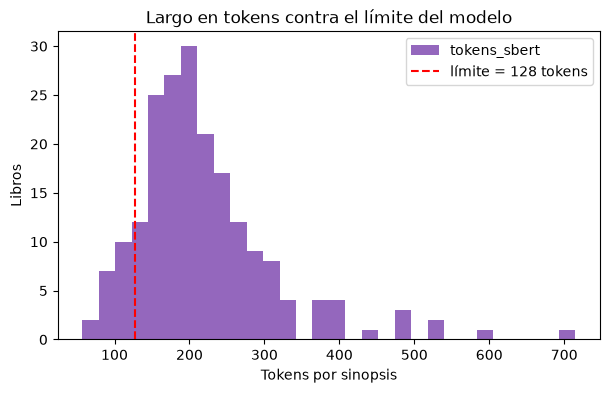

In [18]:
libros["tokens_sbert"] = libros["texto_crudo"].apply(lambda texto: len(sbert.tokenizer.tokenize(texto)) + 2)
truncadas = libros["tokens_sbert"] > limite
perdido = (libros["tokens_sbert"] - limite) / libros["tokens_sbert"]   # fracción del texto que no ve

print(f"Sinopsis truncadas: {truncadas.sum()} de {len(libros)} ({truncadas.mean():.0%})")
print(f"Tokens por sinopsis: mediana {libros['tokens_sbert'].median():.0f}, máximo {libros['tokens_sbert'].max()}")
print(f"En las truncadas, el modelo no ve en promedio el {perdido[truncadas].mean():.0%} final del texto")

libros["tokens_sbert"].plot.hist(bins=30, figsize=(7, 4), color="tab:purple")
plt.axvline(limite, color="red", ls="--", label=f"límite = {limite} tokens")
plt.title("Largo en tokens contra el límite del modelo")
plt.xlabel("Tokens por sinopsis")
plt.ylabel("Libros")
plt.legend()
plt.show()

In [19]:
# Dónde corta una sinopsis: el modelo ve los primeros (límite - 2) tokens
tokens = sbert.tokenizer.tokenize(ejemplo["texto_crudo"])
print(f"«{ejemplo['titulo']}»: {len(tokens) + 2} tokens, el modelo ve {limite}\n")
# convert_tokens_to_string vuelve a unir los pedazos de palabra en texto
print("…", sbert.tokenizer.convert_tokens_to_string(tokens[limite - 2 - 30:limite - 2]), "‖ CORTE ‖")
print("NO LO VE:", sbert.tokenizer.convert_tokens_to_string(tokens[limite - 2:]))

«Harry Potter y la piedra filosofal»: 228 tokens, el modelo ve 128

… un vuelco espectacular. En esa escuela tan especial aprenderá encantamientos, trucos fabulosos y tácticas de ‖ CORTE ‖
NO LO VE: defensa contra las malas artes. Se convertirá en el campeón escolar de quidditch, especie de fútbol aéreo que se juega montado sobre escobas, y se hará un puñado de buenos amigos... aunque también algunos temibles enemigos. Pero sobre todo, conocerá los secretos que le permitirán cumplir con su destino. Pues, aunque no lo parezca a primera vista, Harry no es un chico común y corriente. ¡ Es un mago!


**Qué muestra**

- **178 de las 200 sinopsis (89 %) superan los 128 tokens** y se truncan sin aviso. En esas, el modelo no ve en promedio el **39 % final** del texto.
- La sinopsis mediana tiene 200 tokens pero 136 palabras: el tokenizador multilingüe parte muchas palabras del español en pedazos.
- En *Harry Potter y la piedra filosofal*, el modelo nunca lee que Harry "es un mago": el embedding representa solo el comienzo de la sinopsis.

In [20]:
# Embeddings normalizados (norma 1), guardados en disco para no recalcularlos (lo recomienda el enunciado)
RUTA_SBERT = "data/embeddings_sbert.npy"
if os.path.exists(RUTA_SBERT):
    X_sbert = np.load(RUTA_SBERT)
else:
    X_sbert = sbert.encode(libros["texto_crudo"].tolist(), normalize_embeddings=True)
    np.save(RUTA_SBERT, X_sbert)
assert np.isfinite(X_sbert).all()
MATRICES["SBERT"] = X_sbert
print(f"SBERT: {X_sbert.shape[0]} libros × {X_sbert.shape[1]} dimensiones")

SBERT: 200 libros × 512 dimensiones


## 6.2 El promedio pierde el orden; el modelo de oración, no

Dos oraciones con las mismas palabras en distinto orden, comparadas con SBW (promedio de palabras) y con SBERT.

In [21]:
a, b = "el perro mordió al hombre", "el hombre mordió al perro"
for modelo in ["SBW", "SBERT"]:
    similitud = cosine_similarity(vectorizar_consulta(a, modelo), vectorizar_consulta(b, modelo))[0, 0]
    print(f"{modelo:<6} similitud = {similitud:.3f}")

SBW    similitud = 1.000
SBERT  similitud = 0.990


**Qué muestra**

- Con SBW, las dos oraciones dan **1,000**: sin stopwords quedan las mismas tres palabras, y el promedio no sabe en qué orden estaban.
- SBERT da **0,990**: distingue las dos oraciones, aunque muy poco. Ve el orden, pero en oraciones tan cortas pesan mucho más las palabras que su posición.

## 6.3 Segundo modelo de oración: `multilingual-e5-small`

Lo elegimos de la tabla de MTEB del apunte por dos motivos: **su límite es de 512 tokens** (contra 128 de `distiluse`), así que debería truncar muy pocas sinopsis, y **fue entrenado para búsqueda**, con pares de consulta y pasaje. Por eso necesita un prefijo que indique el papel de cada texto: `"passage: "` para los libros y `"query: "` para las consultas.

In [22]:
e5 = SentenceTransformer("intfloat/multilingual-e5-small")
print(f"Dimensión: {e5.get_embedding_dimension()}")
print(f"Límite de tokens: {e5.max_seq_length}")

# Mismo conteo que para SBERT, con el tokenizador de E5 y el prefijo incluido
tokens_e5 = libros["texto_crudo"].apply(lambda texto: len(e5.tokenizer.tokenize("passage: " + texto)) + 2)
print(f"Sinopsis truncadas: {(tokens_e5 > e5.max_seq_length).sum()} de {len(libros)}")

Dimensión: 384
Límite de tokens: 512
Sinopsis truncadas: 3 de 200


In [23]:
RUTA_E5 = "data/embeddings_e5.npy"
if os.path.exists(RUTA_E5):
    X_e5 = np.load(RUTA_E5)
else:
    X_e5 = e5.encode(["passage: " + texto for texto in libros["texto_crudo"]], normalize_embeddings=True)
    np.save(RUTA_E5, X_e5)
assert np.isfinite(X_e5).all()
MATRICES["E5"] = X_e5
print(f"E5: {X_e5.shape[0]} libros × {X_e5.shape[1]} dimensiones")

E5: 200 libros × 384 dimensiones


**Qué muestra**

- **E5 trunca solo 3 sinopsis**, contra 178 de `distiluse`: con 512 tokens ve prácticamente el texto completo.
- Es más chico (384 dimensiones contra 512).

---
# 7. Comparación y visualización (parte D)

## 7.1 El ejemplo del enunciado: "piratas" contra "bucaneros"

In [24]:
a, b = "una novela sobre piratas", "un relato de bucaneros"
for modelo in MATRICES:
    similitud = cosine_similarity(vectorizar_consulta(a, modelo), vectorizar_consulta(b, modelo))[0, 0]
    print(f"{modelo:<11} similitud = {similitud:.2f}")

TF-IDF      similitud = 0.00
W2V propio  similitud = 0.37
SBW         similitud = 0.78
SBERT       similitud = 0.51
E5          similitud = 0.87


**Qué muestra**

- **TF-IDF da 0:** después de sacar stopwords quedan "novela piratas" y "relato bucaneros", sin ninguna palabra en común.
- Los modelos de embeddings sí las acercan, cada uno en su escala: los valores no se comparan entre modelos (ver la sección 7.2). El 0,51 de SBERT es alto para SBERT, donde dos libros cualesquiera se parecen 0,22.
- El 0,37 del Word2Vec propio sale solo de "novela" y "relato": "piratas" aparece una vez en el corpus y "bucaneros" ninguna, así que no están en su vocabulario.

## 7.2 ¿Cuánto se parecen dos libros cualesquiera?

Un espacio donde todo se parece a todo no discrimina, aunque el ranking igual devuelva resultados. Calculamos la similitud de los 19.900 pares de libros distintos.

        TF-IDF  W2V propio   SBW  SBERT    E5
media     0.02        0.71  0.89   0.22  0.82
desvío    0.02        0.08  0.04   0.09  0.02
mínimo    0.00        0.42  0.67  -0.09  0.74
máximo    1.00        1.00  1.00   1.00  1.00


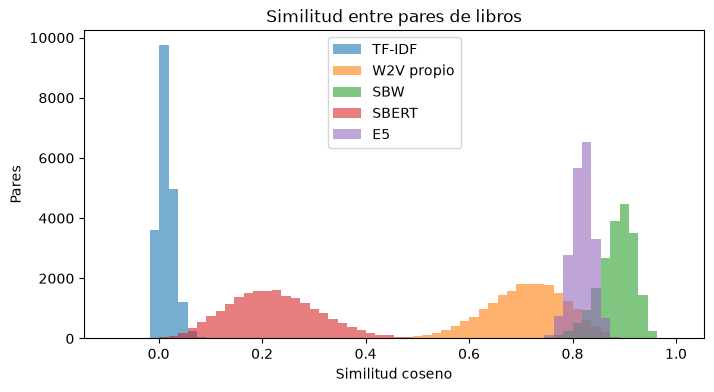

In [25]:
def similitudes_entre_libros(X):
    """Similitud coseno de cada par de libros distintos."""
    S = cosine_similarity(X)   # matriz de 200 × 200: la similitud de cada libro con cada otro
    i, j = np.triu_indices(len(S), k=1)   # índices de los pares sobre la diagonal: cada par una vez
    return S[i, j]


pares_de_libros = pd.DataFrame({modelo: similitudes_entre_libros(X) for modelo, X in MATRICES.items()})
resumen = pares_de_libros.describe().loc[["mean", "std", "min", "max"]].round(2)
print(resumen.rename(index={"mean": "media", "std": "desvío", "min": "mínimo", "max": "máximo"}).to_string())

pares_de_libros.plot.hist(bins=60, alpha=0.6, figsize=(8, 4))
plt.title("Similitud entre pares de libros")
plt.xlabel("Similitud coseno")
plt.ylabel("Pares")
plt.show()

**Qué muestra**

- **TF-IDF (0,02 ± 0,02):** casi todos los pares son ortogonales, porque comparten pocas palabras.
- **SBW (0,89 ± 0,04) y E5 (0,82 ± 0,02): todo se parece a todo.** La diferencia entre un libro muy parecido y uno cualquiera es de pocos centésimos. En SBW, promediar cientos de palabras lleva cada libro hacia el "vector promedio del español".
- **SBERT (0,22 ± 0,09)** es el espacio más repartido; el Word2Vec propio queda en el medio (0,71).
- **Eso no impide ordenar bien** (E5 empata en el primer lugar en la sección 8): para un ranking importa el orden, no el valor. Lo que no se puede es fijar un umbral como "más de 0,8 es relevante".
- El máximo es 1,00 en todos porque *Sapiens* y *De animales a dioses* tienen la misma sinopsis.

## 7.3 Prueba natural: ediciones del mismo libro

Si un modelo captura el significado, la otra edición de un libro debería estar entre sus más parecidos, aunque la sinopsis esté escrita distinto. Medimos en qué puesto queda (1 = el más parecido).

In [26]:
indice = {titulo: n for n, titulo in enumerate(libros["titulo"])}


def puesto_de_la_otra_edicion(X, a, b):
    """Puesto de b al ordenar todos los libros por similitud con a (sin contar a)."""
    i = indice[a]
    similitudes = cosine_similarity(X[i:i + 1], X)[0]   # X[i:i + 1] conserva la forma de matriz de una fila
    similitudes[i] = -1   # el propio libro no cuenta
    orden = list(np.argsort(-similitudes))   # de más a menos parecido
    return orden.index(indice[b]) + 1


puestos = pd.DataFrame({modelo: [puesto_de_la_otra_edicion(X, a, b) for a, b in REPETIDOS]
                        for modelo, X in MATRICES.items()},
                       index=[a[:30] for a, _ in REPETIDOS])
print(puestos.to_string())

                                TF-IDF  W2V propio  SBW  SBERT  E5
1984                                 1         113    4      2   1
Cien años de soledad (Edición        1           1    1      1   1
Rebelión en la granja                1          17    3      1   1
El imperio final                     1           1    1      1   1
Sapiens                              1           1    1      1   1


**Qué muestra**

- **TF-IDF y E5 encuentran todas las otras ediciones en el puesto 1.** TF-IDF lo logra con palabras raras compartidas: las dos sinopsis de *1984* comparten pocas palabras, pero entre ellas están *winston*, *smith*, *partido* y *engranaje*, que casi no aparecen en otros libros. Es un caso donde TF-IDF gana legítimamente.
- SBERT las pone en los puestos 1 o 2, y SBW entre el 1 y el 4.
- **El Word2Vec propio falla con *1984*** (puesto 113) y con *Rebelión en la granja* (17).
- *Sapiens* y *El imperio final* salen primeros en todos, pero no son una prueba difícil: sus sinopsis son iguales o casi. *Cien años de soledad* también sale primero en todos, y ahí sí las dos sinopsis son distintas.

## 7.4 Proyección 2D

Como cada libro tiene varios géneros, hacemos **un panel por género**: en color los libros que lo tienen, en gris el resto. Proyectamos con PCA y, para SBERT, también con t-SNE.

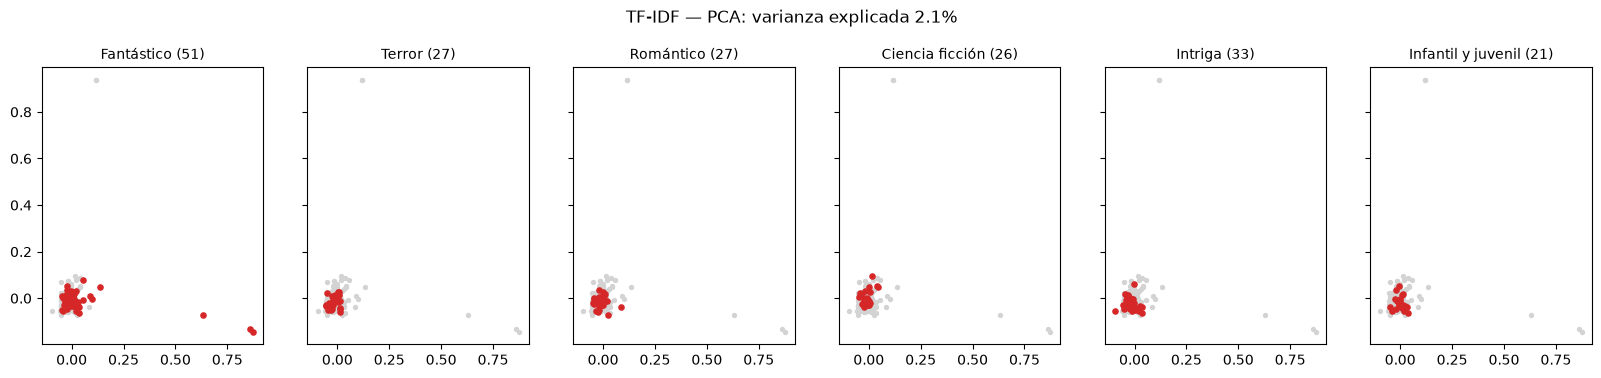

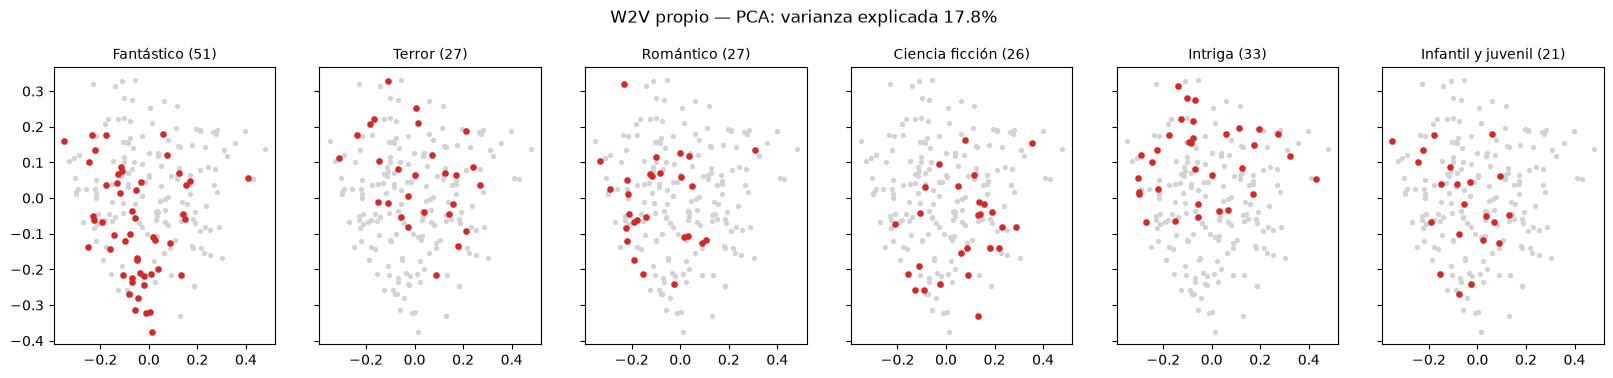

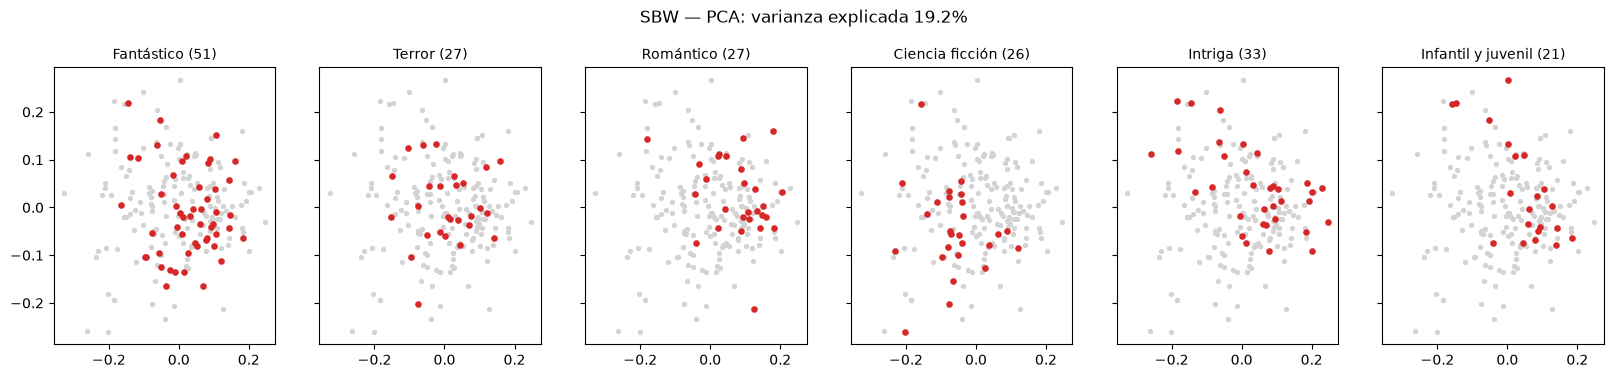

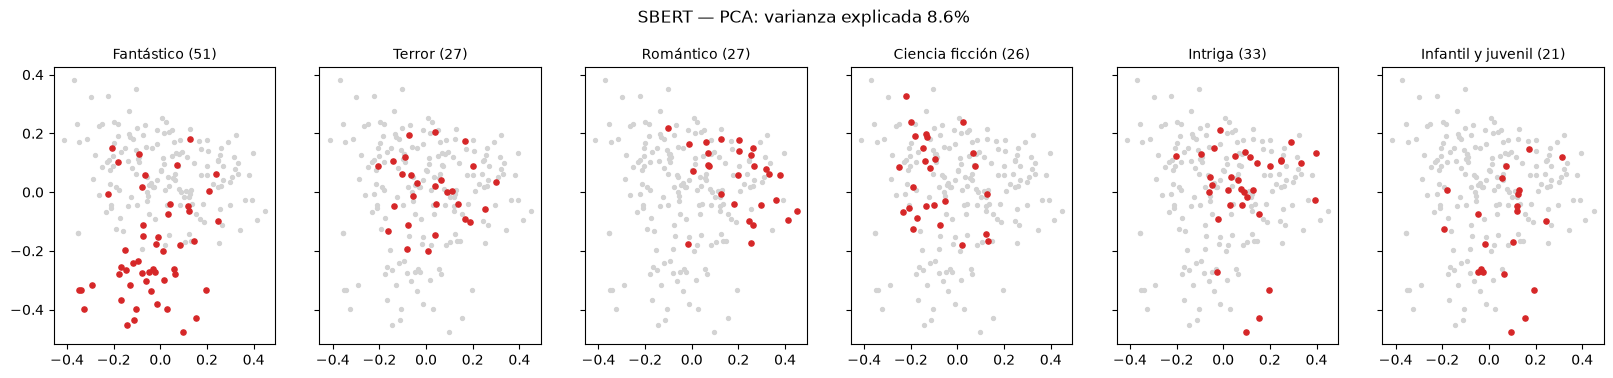

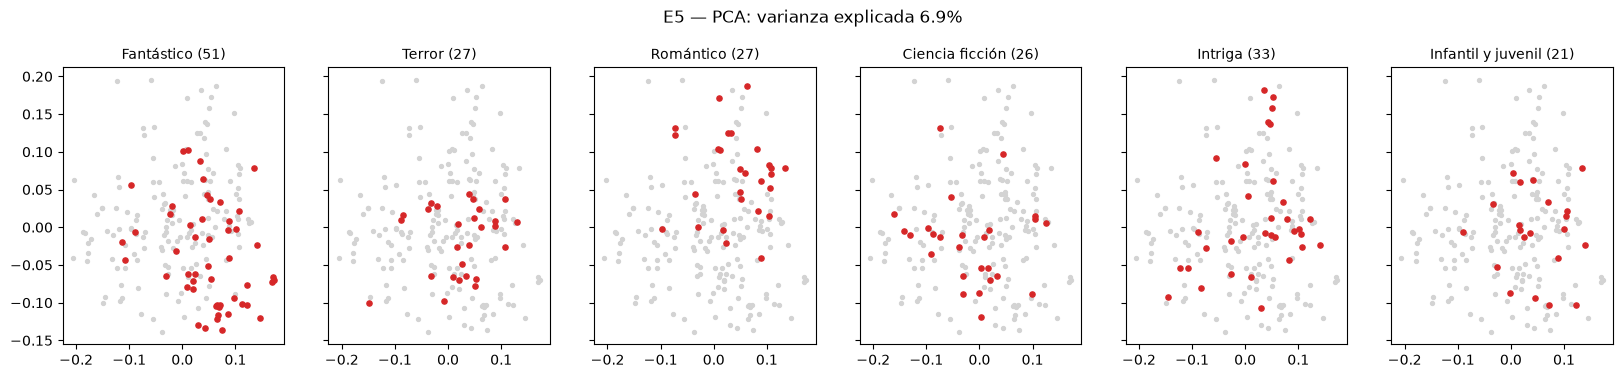

In [27]:
GENEROS_PANEL = ["Fantástico", "Terror", "Romántico", "Ciencia ficción", "Intriga", "Infantil y juvenil"]


def paneles_por_genero(X_2d, titulo):
    fig, axes = plt.subplots(1, len(GENEROS_PANEL), figsize=(20, 3.6), sharex=True, sharey=True)
    for ax, genero in zip(axes, GENEROS_PANEL):
        tiene = libros["lista_generos"].apply(lambda generos: genero in generos).to_numpy()
        ax.scatter(X_2d[~tiene, 0], X_2d[~tiene, 1], s=8, color="lightgray")
        ax.scatter(X_2d[tiene, 0], X_2d[tiene, 1], s=14, color="tab:red")
        ax.set_title(f"{genero} ({tiene.sum()})", fontsize=10)
    fig.suptitle(titulo, y=1.04)
    plt.show()


for modelo, X in MATRICES.items():
    if modelo == "TF-IDF":
        X = X.toarray()   # PCA necesita una matriz común, no sparse
    pca = PCA(n_components=2, random_state=SEMILLA)
    X_2d = pca.fit_transform(X)
    # explained_variance_ratio_: la proporción de la varianza que conserva cada componente
    paneles_por_genero(X_2d, f"{modelo} — PCA: varianza explicada {pca.explained_variance_ratio_.sum():.1%}")

**Qué muestra**

- **TF-IDF (2,1 %):** las dos componentes solo capturan duplicados: los tres libros de *Nacidos de la bruma*, que repiten el texto promocional de la saga, y *Sapiens* con *De animales a dioses*. El resto queda amontonado.
- **SBW (19,2 %) y Word2Vec propio (17,8 %):** explican más varianza, pero no aparecen regiones por género.
- **SBERT (8,6 %)** muestra las regiones más claras: Fantástico abajo a la izquierda, Romántico a la derecha y Ciencia ficción arriba a la izquierda. **E5 (6,9 %)** también, con más superposición.
- **Advertencia:** en ningún modelo las dos componentes llegan al 20 % de la varianza. Una nube mezclada en 2D puede estar separada en el espacio original, y explicar más varianza (SBW) no significa separar mejor los géneros.

**t-SNE con SBERT.** A diferencia de PCA, t-SNE no es lineal: busca que los libros cercanos en el espacio original queden cerca en el plano. La `perplexity` es, aproximadamente, cuántos vecinos considera cada punto: usamos **15**, menos que el valor por defecto (30), porque los géneros del panel tienen entre 21 y 51 libros.

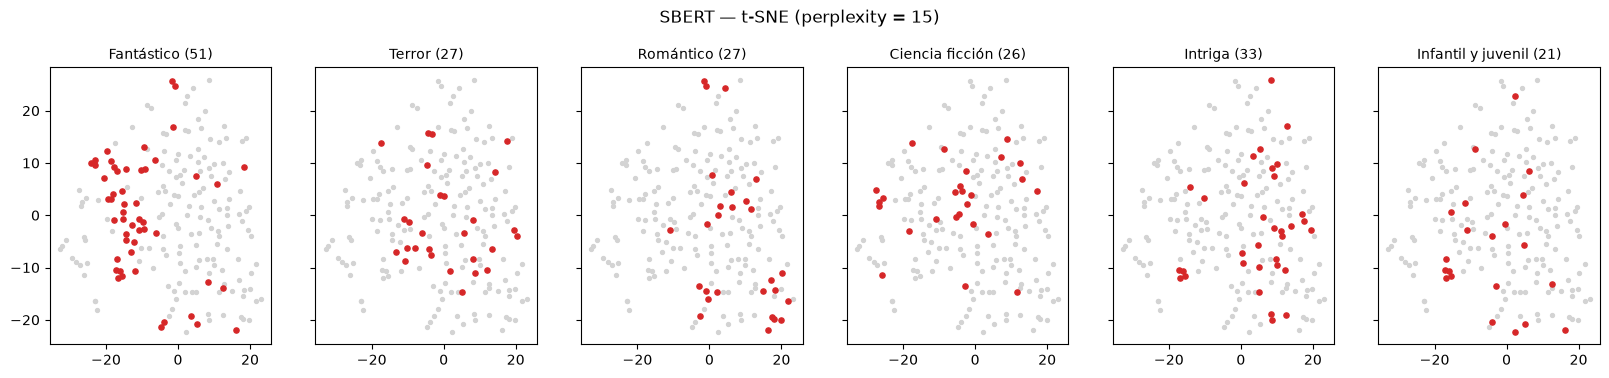

In [28]:
tsne = TSNE(n_components=2, perplexity=15, random_state=SEMILLA)
paneles_por_genero(tsne.fit_transform(X_sbert), "SBERT — t-SNE (perplexity = 15)")

**Qué muestra**

- Con t-SNE, **Fantástico forma un grupo bien definido** a la izquierda, más claro que con PCA. Romántico e Intriga se concentran en zonas, y Terror y Ciencia ficción quedan más repartidos.
- **Cuidado al leerlo:** t-SNE conserva los vecindarios, no las distancias globales. La distancia entre grupos y su tamaño no significan nada, y el dibujo cambia con la `perplexity` y la semilla. Por eso no tiene "varianza explicada".

## 7.5 Rankings lado a lado

Tres consultas de `queries.json`: una con palabras en común con sus libros relevantes (q04), una sin ninguna (q03) y una en inglés (q07). Con ✓ se marcan los libros relevantes.

> `queries.json` se escribió y se commiteó **antes** de correr cualquier ranking: los libros relevantes se decidieron leyendo las sinopsis.

In [29]:
queries = json.load(open(RUTA_QUERIES, encoding="utf-8"))


def ranking_lado_a_lado(id_consulta, k=5):
    q = next(q for q in queries if q["id"] == id_consulta)
    print(f"«{q['consulta']}» · {q['tipo']} · {len(q['relevantes'])} relevantes")
    tabla = {}
    for modelo in MATRICES:
        recuperados = buscar(q["consulta"], modelo, k=k)["titulo"]
        tabla[modelo] = [("✓ " if titulo in q["relevantes"] else "· ") + titulo[:32] for titulo in recuperados]
    return pd.DataFrame(tabla, index=range(1, k + 1))


for id_consulta in ["q04", "q03", "q07"]:
    display(ranking_lado_a_lado(id_consulta))

«un asesino en serie y la investigación para atraparlo» · trama · 6 relevantes


,TF-IDF,W2V propio,SBW,SBERT,E5
1,✓ No soy un serial killer,✓ No soy un serial killer,✓ No soy un serial killer,✓ El Cuarto Mono,✓ El Cuarto Mono
2,✓ El guardián invisible,✓ El Cuarto Mono,✓ El Cuarto Mono,· El visitante,✓ No soy un serial killer
3,✓ El Cuarto Mono,· Carrie,· La verdad sobre el caso Harry Qu,· El día que se perdió la cordura,· El visitante
4,· Palabras radiantes,✓ La novia gitana,· El visitante,✓ No soy un serial killer,· Asylum
5,· La llamada de Cthulhu,✓ El guardián invisible,· Harry Potter y la cámara secreta,· La verdad sobre el caso Harry Qu,· El psicoanalista


«una pandemia diezma a la población mundial» · sin palabras en común · 3 relevantes


,TF-IDF,W2V propio,SBW,SBERT,E5
1,· Mi Lucha,· Origen,✓ Apocalipsis,· Cadáver exquisito,· Cadáver exquisito
2,· Parque Jurásico,· Parque Jurásico,· Cadáver exquisito,· La Reina Roja,· Sapiens
3,· Fahrenheit 451,· Palabras radiantes,· Parque Jurásico,· Indigno de ser humano,· De animales a dioses
4,· El guardián invisible,· It,✓ Soy leyenda,✓ Apocalipsis,· Fahrenheit 451
5,· Origen,· La casa de los espíritus,· Sapiens,· Trilogía Los juegos del hambre,· El problema de los Tres Cuerpos


«a creepy mansion haunted by ghosts» · en otro idioma (sin palabras en común) · 4 relevantes


,TF-IDF,W2V propio,SBW,SBERT,E5
1,· La chica del tren,· La chica del tren,✓ La maldición de Hill House,✓ El misterio de Salem’s Lot,· La asistenta
2,· El libro negro de la Nueva Izqui,· El libro negro de la Nueva Izqui,· El caballero de la armadura oxid,✓ El cuento número trece,· Un monstruo viene a verme
3,· Ready Player One,· Ready Player One,· Harry Potter. La colección compl,· El hogar de Miss Peregrine para,· El secreto de la asistenta
4,· It,· It,· Ready Player One,· La llamada de Cthulhu,✓ El misterio de Salem’s Lot
5,· La verdad sobre el caso Harry Qu,· La verdad sobre el caso Harry Qu,· Tal vez mañana,· Entrevista con el vampiro,· Diez negritos


**Qué muestra**

- **q04 (con palabras en común):** todos aciertan entre 2 y 4. TF-IDF encuentra *No soy un serial killer*, *El guardián invisible* y *El Cuarto Mono* por "asesino" y "serie". Los modelos de oración traen además thrillers sin asesino en serie (*El visitante*).
- **q03 (sin palabras en común):** TF-IDF y el Word2Vec propio no encuentran ninguno. SBW encuentra *Apocalipsis* y *Soy leyenda*, y SBERT, *Apocalipsis*. SBERT y E5 ponen primero *Cadáver exquisito*, que según nuestro criterio no es relevante (el virus ataca a los animales): es un caso límite, y no cambiamos el criterio después de ver los resultados.
- **q07 (en inglés):** TF-IDF y el Word2Vec propio no conocen ninguna palabra de la consulta; su vector queda en cero y devuelven los primeros libros del corpus. **SBERT acierta 2** (*El misterio de Salem's Lot* y *El cuento número trece*): al ser multilingüe, ubica la consulta en inglés cerca de sinopsis en español que dicen lo mismo.

---
# 8. Evaluación con precision@k (sección 5)

- **precision@5:** de los 5 libros que devuelve el modelo, qué proporción es relevante según `queries.json`.
- **Piso de azar:** un ranking al azar acierta, en promedio, `relevantes / 200` en cada puesto.
- `queries.json` tiene 13 consultas de tres tipos: de **trama**, **temáticas** y **sin palabras en común** con sus libros relevantes (una de ellas, en inglés).

In [30]:
K = 5


def precision_at_k(recuperados, relevantes, k=K):
    return len(set(recuperados[:k]) & set(relevantes)) / k


# Controles de queries.json: los títulos existen, las dos ediciones de un libro repetido van juntas
# y las consultas "sin palabras en común" de verdad no comparten palabras con sus libros relevantes
tokens_del_libro = dict(zip(libros["titulo"], libros["tokens"]))
for q in queries:
    assert all(titulo in titulos for titulo in q["relevantes"]), q["id"]
    for a, b in REPETIDOS:
        assert (a in q["relevantes"]) == (b in q["relevantes"]), q["id"]
    if "sin palabras en común" in q["tipo"]:
        for titulo in q["relevantes"]:
            assert not set(tokenizar(q["consulta"])) & set(tokens_del_libro[titulo]), (q["id"], titulo)
print(f"{len(queries)} consultas: controles de queries.json superados\n")

filas = []
for q in queries:
    fila = {"id": q["id"], "tipo": q["tipo"], "relevantes": len(q["relevantes"]),
            "azar": len(q["relevantes"]) / len(libros)}
    for modelo in MATRICES:
        recuperados = buscar(q["consulta"], modelo, k=K)["titulo"].tolist()
        fila[modelo] = precision_at_k(recuperados, q["relevantes"])
    filas.append(fila)
resultados = pd.DataFrame(filas).set_index("id")

modelos = list(MATRICES)
print(resultados[["relevantes", "azar"] + modelos].round(2).to_string())
promedio = resultados[["azar"] + modelos].mean()
print("\nPromedio:")
print(promedio.round(3).to_string())

13 consultas: controles de queries.json superados



     relevantes  azar  TF-IDF  W2V propio  SBW  SBERT   E5
id                                                        
q01           5  0.02     0.8         0.2  0.2    0.6  0.6
q02           5  0.02     0.6         0.4  0.4    0.6  0.6
q03           3  0.02     0.0         0.0  0.4    0.2  0.0
q04           6  0.03     0.6         0.8  0.4    0.4  0.4
q05           9  0.04     1.0         0.6  0.6    0.2  0.6
q06           5  0.02     0.4         0.0  0.0    0.4  0.4
q07           4  0.02     0.0         0.0  0.2    0.4  0.2
q08           7  0.04     0.4         0.6  0.6    0.0  0.0
q09           7  0.04     0.4         0.8  0.6    0.8  1.0
q10           2  0.01     0.0         0.2  0.2    0.2  0.2
q11           4  0.02     0.0         0.0  0.2    0.6  0.2
q12          10  0.05     0.8         0.0  0.4    0.8  1.0
q13           3  0.02     0.0         0.0  0.0    0.0  0.0

Promedio:
azar          0.027
TF-IDF        0.385
W2V propio    0.277
SBW           0.323
SBERT         0.400
E5  

                       azar  TF-IDF  W2V propio   SBW  SBERT    E5
grupo                                                             
sin palabras en común  0.02     0.0        0.00  0.27   0.40  0.13
temática               0.04     0.6        0.40  0.44   0.44  0.60
trama                  0.02     0.4        0.32  0.24   0.36  0.36


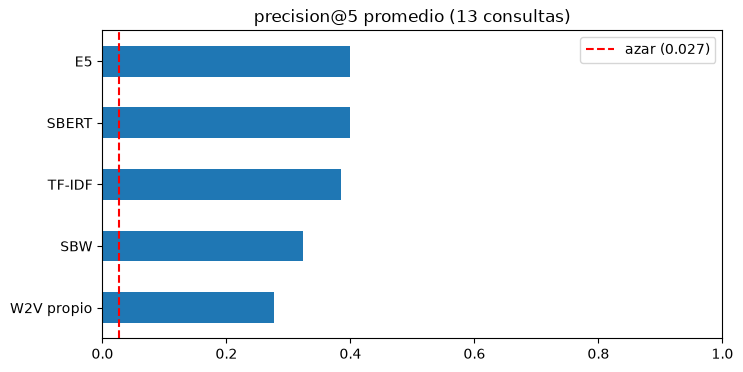

W2V propio contra TF-IDF: gana 4, empata 4, pierde 5
SBW        contra TF-IDF: gana 6, empata 1, pierde 6
SBERT      contra TF-IDF: gana 5, empata 4, pierde 4
E5         contra TF-IDF: gana 5, empata 4, pierde 4


In [31]:
# Por tipo de consulta (la consulta en inglés cuenta como "sin palabras en común")
resultados["grupo"] = resultados["tipo"].replace({"en otro idioma (sin palabras en común)": "sin palabras en común"})
print(resultados.groupby("grupo")[["azar"] + modelos].mean().round(2).to_string())

promedio[modelos].sort_values().plot.barh(figsize=(8, 4))
plt.axvline(promedio["azar"], color="red", ls="--", label=f"azar ({promedio['azar']:.3f})")
plt.title(f"precision@{K} promedio ({len(queries)} consultas)")
plt.xlim(0, 1)
plt.legend()
plt.show()

# Consulta por consulta: cuántas veces cada modelo le gana, empata o pierde contra TF-IDF
for modelo in modelos[1:]:
    diferencia = resultados[modelo] - resultados["TF-IDF"]
    print(f"{modelo:<10} contra TF-IDF: gana {(diferencia > 0).sum()}, empata {(diferencia == 0).sum()}, "
          f"pierde {(diferencia < 0).sum()}")

**Qué muestra**

- **Todos superan ampliamente el azar (0,027):** cada consulta tiene entre 2 y 10 relevantes entre 200.
- **Los modelos de oración empatan con TF-IDF:** 0,400 contra 0,385 es **un solo libro** de diferencia en 65 posiciones evaluadas. Consulta por consulta, SBERT y E5 le ganan en 5, empatan en 4 y pierden en 4.
- **La diferencia está en el tipo de consulta:** sin palabras en común, TF-IDF saca 0 por construcción y SBERT 0,40; en las temáticas, TF-IDF empata con E5 (0,60), y en las de trama queda primero (0,40).
- **El Word2Vec propio es el peor (0,277)** y SBW queda en el medio (0,323): resuelve algunas consultas sin coincidencia léxica (q03), pero el "todo se parece a todo" le quita precisión.

**Qué no mide precision@5:** el orden dentro de los 5 ni los relevantes que quedan afuera (recall), y su máximo depende de cuántos relevantes tiene la consulta (con 2, como q10, no supera 0,4). Con 13 consultas, cada acierto mueve el promedio 0,015: las diferencias de pocos centésimos entre modelos son ruido.

## 8.1 Dos casos de falla

Para cada consulta, el ranking y el puesto de cada libro relevante dentro del ranking completo de los 200 (1 = primero).

In [32]:
def puestos_de_los_relevantes(id_consulta):
    q = next(q for q in queries if q["id"] == id_consulta)
    columnas = {}
    for modelo in MATRICES:
        ranking = buscar(q["consulta"], modelo, k=len(libros))["titulo"].tolist()
        columnas[modelo] = sorted(ranking.index(titulo) + 1 for titulo in q["relevantes"])
    return pd.DataFrame(columnas, index=range(1, len(q["relevantes"]) + 1)).rename_axis("relevante")


for id_consulta in ["q08", "q13"]:
    display(ranking_lado_a_lado(id_consulta))
    display(puestos_de_los_relevantes(id_consulta))

«novelas sobre el amor por los libros y la lectura» · temática · 7 relevantes


,TF-IDF,W2V propio,SBW,SBERT,E5
1,✓ El juego del ángel,✓ El juego del ángel,✓ La Historia Interminable – Color,· Como agua para chocolate,· El día que el cielo se caiga
2,✓ La sombra del viento,✓ La sombra del viento,· Cien años de soledad (Ed. Ilustr,· La casa de los espíritus,· El chico que dibujaba constelaci
3,· Harry Potter. La colección compl,· Cumbres borrascosas (ed. Alba),✓ El juego del ángel,· A todos los chicos de los que me,· Yo antes de ti
4,· El niño con el pijama de rayas,· Rebelión en la granja (trad. Mar,✓ La sombra del viento,· El día que dejó de nevar en Alas,· Como agua para chocolate
5,· El problema de los Tres Cuerpos,✓ Fahrenheit 451,· Cumbres borrascosas (ed. Alba),· Bajo la misma estrella,· After


,TF-IDF,W2V propio,SBW,SBERT,E5
relevante,,,,,
1,1,1,1,7,7
2,2,2,3,11,16
3,13,5,4,19,18
4,14,7,8,35,26
5,16,38,14,43,33
6,35,45,19,51,76
7,177,102,55,53,121


«un crimen misterioso en un lugar aislado del que nadie puede salir» · trama · 3 relevantes


,TF-IDF,W2V propio,SBW,SBERT,E5
1,· El juego del ángel,· Escuadrón,· No soy un serial killer,· El Cuarto Mono,· El instituto
2,· Jumper,· Asylum,· Maze Runner: Correr o morir,· El día que se perdió la cordura,· Maze Runner: Correr o morir
3,· El bestiario de Axlin,· Edenbrooke,· Edenbrooke,· El extranjero,· Asylum
4,· El día que dejó de nevar en Alas,· Jumper,· La paciente silenciosa,· El temor de un hombre sabio,· La paciente silenciosa
5,· El Cuarto Mono,"· Hush, Hush",· El bestiario de Axlin,· La sombra del viento,· La verdad sobre el caso Harry Qu


,TF-IDF,W2V propio,SBW,SBERT,E5
relevante,,,,,
1,13,39,13,14,10
2,32,144,125,27,12
3,56,178,177,39,192


**Caso 1. q08, "novelas sobre el amor por los libros y la lectura": fallan los modelos de oración.**

- SBERT y E5 devuelven solo novelas románticas (*Como agua para chocolate*, *Yo antes de ti*, *After*), y su primer relevante aparece recién en el puesto 7. TF-IDF, el Word2Vec propio y SBW aciertan 2 o 3. TF-IDF encuentra *La sombra del viento* y *El juego del ángel* porque comparten con la consulta "amor" y "libros".
- **Hipótesis:** el modelo de oración representa la consulta entera, y su significado dominante es "amor". Pero acá el amor no es romántico. Como el corpus tiene muchas novelas románticas, esa región del espacio gana.

**Caso 2. q13, "un crimen misterioso en un lugar aislado del que nadie puede salir": fallan todos.**

- Ningún modelo pone un relevante entre los 5 primeros; el mejor puesto es el 9 (E5). E5 trae historias de encierro (*El instituto*, *Maze Runner*, *Asylum*), y SBERT, thrillers (*El Cuarto Mono*).
- **Hipótesis:** la consulta mezcla dos ideas, el crimen y el encierro, y cada modelo se queda con una. Las sinopsis relevantes no hablan de encierro: dicen "una tormenta de nieve ha obligado a detener el tren", "uno de los islotes", "una abadía benedictina". La relación con "aislado" la hace el lector, no el texto.